# Actividad Práctica U2
## Proyecto: Análisis de sentimiento y tendencias en redes sociales
### Fase 1: Extracción y tratamiento de datos

In [1]:
import pandas as pd
import re
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
class DataExtractor:
    def __init__(self, source_file: str, chunksize: int = 100000):
        """
        Inicializa el extractor con el archivo de origen.

        Parámetros:
        - source_file: ruta al archivo CSV o JSON.
        - chunksize: tamaño de bloque para leer archivos grandes.
        """
        self.source_file = source_file
        self.data = None
        self.chunksize = chunksize

    def load_data(self):
        """
        Carga los datos del archivo de origen y los almacena en self.data.
        """
        if not os.path.exists(self.source_file):
            raise FileNotFoundError(f"File {self.source_file} not found.")

        if self.source_file.endswith(".csv"):
            reader = pd.read_csv(self.source_file, encoding="utf-8", engine="python", chunksize=self.chunksize, on_bad_lines='skip')
            self.data = pd.concat(reader, ignore_index=True)
        elif self.source_file.endswith(".json"):
            self.data = pd.read_json(self.source_file, encoding="utf-8", lines=True)
        else:
            raise ValueError("Unsupported file format. Please use CSV or JSON.")

        return self.data

    def clean_text(self, text: str) -> str:
        """
        Limpia y normaliza un texto.
        """
        # validar texto
        if not isinstance(text, str):
            return ""
        # pasar a minúsculas
        text = text.lower()
        # quitar urls
        text = re.sub(r'http\S+|www\S+', "", text)
        # quitar menciones
        text = re.sub(r'@\w+', "", text)
        # quitar caracteres especiales excepto hashtags
        text = re.sub(r'[^\w\s#]', "", text)
        # compactar espacios
        text = re.sub(r'\s+', " ", text)
        text = text.strip()
        # devolver texto limpio
        return text

    def extract_hashtags(self, text: str) -> list:
        """
        Extrae hashtags de un texto.
        """
        # validar input
        if not isinstance(text, str):
            return []
        # aplicar regex
        hashtags = re.findall(r'#\w+', text)
        # devolver lista
        return hashtags

    def analytics_hashtags_extended(self) -> dict:
        """
        Realiza análisis global, por usuario y por fecha de los hashtags.
        """

        if self.data is None:
            raise ValueError("Data not loaded. Please call load_data() first.")

        df = self.data.copy()
        df["cleaned_text"] = df["text"].apply(self.clean_text)
        df["hashtags"] = df["cleaned_text"].apply(self.extract_hashtags)
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
        df_exploded = df.explode("hashtags").dropna(subset=["hashtags"])

        overall = (
            df_exploded["hashtags"]
            .value_counts()
            .reset_index()
        )
        overall.columns = ["hashtag", "frecuency"]

        by_user = (
            df_exploded
            .groupby(["user_name", "hashtags"])
            .size()
            .reset_index(name="frequency")
        )
        by_user.columns = ["user_name", "hashtag", "frequency"]

        by_date = (
            df_exploded
            .groupby(["date", "hashtags"])
            .size()
            .reset_index(name="frequency")
        )
        by_date.columns = ["date", "hashtag", "frequency"]

        return {'overall': overall, 'by_user': by_user, 'by_date': by_date}

    def generate_hashtag_wordcloud(self, overall_df: pd.DataFrame = None, max_words: int = 100, figsize: tuple = (10, 6)) -> None:
        """
        Genera una wordcloud de hashtags.
        """

        if overall_df is None:
            if self.data is None:
                raise ValueError("Data not loaded. Please call load_data() first.")
            overall_df = self.analytics_hashtags_extended()['overall']

        hashtag_freq = dict(zip(overall_df["hashtag"], overall_df["frecuency"]))

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            max_words=max_words
        ).generate_from_frequencies(hashtag_freq)

        plt.figure(figsize=figsize)
        plt.title("WordCloud de Hashtags")
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.show()


## 1) Carga de datos, almacenamiento y análisis inicial

In [3]:
file_path = "data/Bitcoin_tweets_dataset_2.csv"
extractor = DataExtractor(file_path)
df = extractor.load_data()
df.head()


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,ChefSam,Sunshine State,Culinarian | Hot Sauce Artisan | Kombucha Brew...,2011-03-23 03:50:13,4680.0,2643.0,6232,False,2023-03-01 23:59:59,Which #bitcoin books should I think about read...,['bitcoin'],Twitter for iPhone,False
1,Roy⚡️,NaN,Truth-seeking pleb 📚 • Science 🧪 • Nature 🌱☀️ ...,2022-01-30 17:41:41,770.0,1145.0,9166,False,2023-03-01 23:59:47,"@ThankGodForBTC I appreciate the message, but ...",['Bitcoin'],Twitter for iPhone,False
2,Ethereum Yoda,NaN,UP or DOWN...\n.\n.\n.\n.\nPrice matters NOT.,2022-07-24 04:50:18,576.0,1.0,0,False,2023-03-01 23:59:42,#Ethereum price update: \n\n#ETH $1664.02 USD\...,"['Ethereum', 'ETH', 'Bitcoin', 'BTC', 'altcoin...",Twitter Web App,False
3,Viction,"Paris, France",https://t.co/8M3rgdjwEe\n\n#bitcoin #blockchai...,2010-03-26 10:15:26,236.0,1829.0,2195,False,2023-03-01 23:59:36,CoinDashboard v3.0 is here\nAvailable on ios a...,['Bitcoin'],Twitter for Android,False
4,Rosie,London,"The flower language of jasmine is loyalty, res...",2013-02-16 09:57:56,12731.0,46.0,134,False,2023-03-01 23:59:32,#Bitcoin Short Term Fractal (4H)💥\n\nIn lower ...,"['Bitcoin', 'BTC']",Twitter Web App,False


## 2) Limpieza y normalización de texto

In [4]:
for i, row in df.iterrows():
    text_test = row.get("text", "")
    cleaned_text = extractor.clean_text(text_test)
    print(f"{i}. Original: {text_test}\nLimpio: {cleaned_text}\n")
    if i >= 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Original: Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB
Limpio: which #bitcoin books should i think about reading next

1. Original: @ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with #Bitcoin.
Limpio: i appreciate the message but not a fan of the religious references religion has nothing to do with #bitcoin

2. Original: #Ethereum price update: 

#ETH $1664.02 USD
#Bitcoin 0.070428 #BTC

Follow for recent ETH price updates
#altcoin, #cryptocurrency, #crypto
Limpio: #ethereum price update #eth 166402 usd #bitcoin 0070428 #btc follow for recent eth price updates #altcoin #cryptocurrency #crypto

3. Original: CoinDashboard v3.0 is here
Available on ios and Android
#Bitcoin https://t.co/tMCQllv9rj
Limpio: coindashboard v30 is here available on ios and android #bitcoin

4. Original: #Bitcoin Short Term Fractal (4H)💥

In lower timeframe, #BTC price action seems to be repeating itself while

## 3) Análisis básico - Extracción de hashtags

In [5]:
for i, row in df.iterrows():
    text_test = row.get("text", "")
    text_hashtags = extractor.extract_hashtags(text_test)
    print(f"{i}. Texto: {text_test}\nHashtags: {text_hashtags}\n")
    if i > 9:  # Limitar a las primeras 10 filas para evitar demasiada salida
        break

0. Texto: Which #bitcoin books should I think about reading next? https://t.co/32gas26rKB
Hashtags: ['#bitcoin']

1. Texto: @ThankGodForBTC I appreciate the message, but not a fan of the religious references. Religion has nothing to do with #Bitcoin.
Hashtags: ['#Bitcoin']

2. Texto: #Ethereum price update: 

#ETH $1664.02 USD
#Bitcoin 0.070428 #BTC

Follow for recent ETH price updates
#altcoin, #cryptocurrency, #crypto
Hashtags: ['#Ethereum', '#ETH', '#Bitcoin', '#BTC', '#altcoin', '#cryptocurrency', '#crypto']

3. Texto: CoinDashboard v3.0 is here
Available on ios and Android
#Bitcoin https://t.co/tMCQllv9rj
Hashtags: ['#Bitcoin']

4. Texto: #Bitcoin Short Term Fractal (4H)💥

In lower timeframe, #BTC price action seems to be repeating itself while LMACD is reproducing the same sequence. 🫡 https://t.co/2MG9yL7SDa
Hashtags: ['#Bitcoin', '#BTC']

5. Texto: Y’all Message me for any account recovery or hacking #CYBER #security #Coinbase #Bitcoin #BNB #facebook #snapchat #instagram.
Hashta

## 4) Análisis avanzado - Tendencias de hashtags

In [6]:
extractor = DataExtractor(file_path)
extractor.load_data()
hashtag_analysis = extractor.analytics_hashtags_extended()

In [7]:
hashtag_analysis['overall'].head()

,hashtag,frecuency
0,#bitcoin,154528
1,#btc,66594
2,#crypto,62556
3,#cryptocurrency,34543
4,#eth,33052


In [8]:
hashtag_analysis['by_user'].head()

,user_name,hashtag,frequency
0,! Nett SOL,#blockchain,2
1,! Nett SOL,#btc,2
2,! Nett SOL,#crypto,3
3,! Nett SOL,#cryptocurrencymarket,1
4,! Nett SOL,#decentralized,2


In [9]:
hashtag_analysis['by_date'].head()

,date,hashtag,frequency
0,2023-02-25,#1,8
1,2023-02-25,#10000x,1
2,2023-02-25,#1000x,1
3,2023-02-25,#1000xgem,2
4,2023-02-25,#100daysofcode,5


## 5) Visualización - WordCloud de hashtags

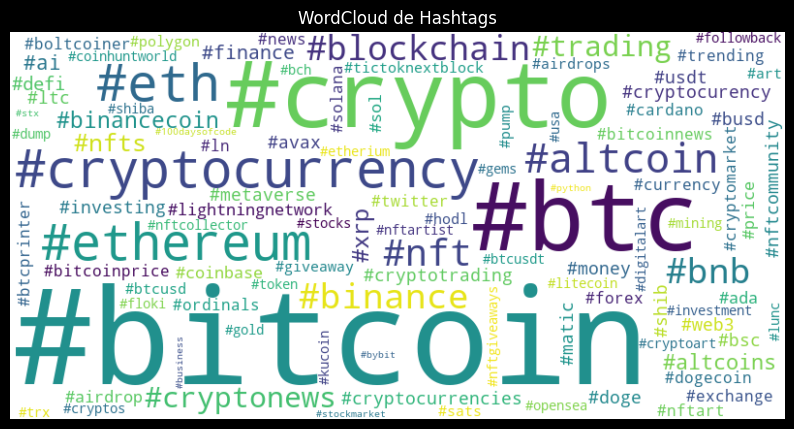

In [10]:
extractor.generate_hashtag_wordcloud(overall_df=hashtag_analysis['overall'])